['__ON__' 'NACHT' 'REGION' 'REGEN' 'cl-KOMMEN' 'REGEN' 'REGION' 'KLAR'
 'STERN' 'SEHEN']


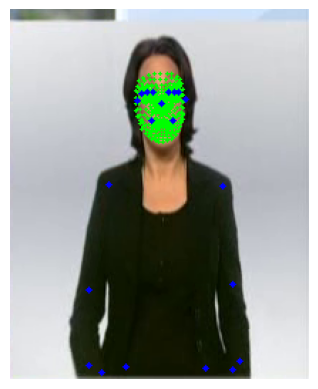

In [34]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import os
import numpy as np
import torch
from torch.utils.data import Dataset
import cv2
import matplotlib.pyplot as plt

class LandmarkDataset(Dataset):
    def __init__(self, landmarks_dir):
        self.file_paths = sorted([os.path.join(landmarks_dir, f) for f in os.listdir(landmarks_dir) if f.endswith(".npz")])

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        data = np.load(self.file_paths[idx])
        landmarks = torch.tensor(data["landmarks"]).float()
        label_str = data["glosses"]
        return landmarks, label_str


class SignLanguageLSTM(nn.Module):
    def __init__(self, input_dim=1530, hidden_dim=128, num_classes=100):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        output, _ = self.lstm(x)
        output = self.fc(output[:, -1, :])
        return output

def compute_accuracy(output, target):
    preds = output.argmax(dim=1)
    correct = (preds == target).sum().item()
    return correct, target.size(0)

def train(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0
    correct = 0
    total = 0
    for landmarks, labels in dataloader:
        landmarks, labels = landmarks.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(landmarks)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        c, t = compute_accuracy(outputs, labels)
        correct += c
        total += t
    print(f"Train Loss: {running_loss / len(dataloader):.4f}, Accuracy: {correct / total:.4f}")

def evaluate(model, dataloader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for landmarks, labels in dataloader:
            landmarks, labels = landmarks.to(device), labels.to(device)
            outputs = model(landmarks)
            c, t = compute_accuracy(outputs, labels)
            correct += c
            total += t
    print(f"Eval Accuracy: {correct / total:.4f}")

def overlay_landmarks(image, landmarks):
    # image shape: (H, W, 3), landmarks shape: (1629,) for one frame
    overlay = image.copy()
    h, w = image.shape[:2]

    # 2 hands: first 126 dims (=2×21×3)
    for hand in range(2):
        offset = hand * 63
        for i in range(21):
            x, y, z = landmarks[offset + i*3 : offset + i*3 + 3]
            # Only plot if landmark is nonzero (detected)
            if x != 0 or y != 0:
                cx = int(x * w)
                cy = int(y * h)
                cv2.circle(overlay, (cx, cy), 2, (255,0,0), -1)

    # face: next 1404 dims (468×3)
    for i in range(468):
        x, y, z = landmarks[126 + i*3 : 126 + i*3 + 3]
        if x != 0 or y != 0:
            cx = int(x * w)
            cy = int(y * h)
            cv2.circle(overlay, (cx, cy), 1, (0,255,0), -1)

    # pose: last 99 dims (33×3)
    for i in range(33):
        x, y, z = landmarks[126 + 1404 + i*3 : 126 + 1404 + i*3 + 3]
        if x != 0 or y != 0:
            cx = int(x * w)
            cy = int(y * h)
            cv2.circle(overlay, (cx, cy), 2, (0,0,255), -1)

    return overlay

if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Load your vocab here (same vocab used for preprocessing)
    vocab = {'__ON__':0} # e.g. {'__ON__':0, 'LIEB':1, ...}

    train_ds = LandmarkDataset("./landmarks_train", vocab)

    landmarks_tensor, label_str = train_ds[10]
    # landmarks_tensor shape: (T, feature_dim)
    landmarks_frame = landmarks_tensor[0].numpy()  # convert tensor to numpy array for overlay function

    print (label_str)

    img = cv2.imread('phoenix-2014.v3.tar/phoenix2014-release/phoenix-2014-multisigner/features/fullFrame-210x260px/train/06October_2012_Saturday_tagesschau_default-5/1/06October_2012_Saturday_tagesschau.avi_pid0_fn000000-0.png')
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    overlay_img = overlay_landmarks(img, landmarks_frame)

    plt.imshow(overlay_img)
    plt.axis('off')
    plt.show()
